In [123]:
import requests
import pandas as pd
from time import sleep

# === Parameters ===
FROM_YEAR = 2022
TO_YEAR = 2025
ROWS_PER_PAGE = 100
MAX_PAGES = 2

TOPIC_QUERIES = [
    '"vessel scheduling" + "reinforcement learning"',
    '"vessel rotation planning" + "reinforcement learning"',
    '"berth allocation" + "reinforcement learning"',
    '"container terminal" + "reinforcement learning"',
    '"maritime logistics" + "reinforcement learning"',
    '"port optimization" + "reinforcement learning"',
    '"port scheduling" + "reinforcement learning"',
    '"maritime transport" + "reinforcement learning"',
]

RL_METHODS = [
    "PPO", "Proximal Policy Optimization", "Q-learning", "DQN",
    "Deep Q Network", "Actor-Critic", "Reinforcement Learning",
    "Deep Reinforcement Learning", "Multi-Agent Reinforcement Learning"
]

# === Crossref Fetch ===
def fetch_crossref_results(query, from_year, to_year, rows_per_page, max_pages):
    records = []
    for page in range(max_pages):
        url = (
            f"https://api.crossref.org/works?"
            f"query={query}"
            f"&filter=from-pub-date:{from_year},until-pub-date:{to_year},"
            f"type:journal-article,has-license:true"
            f"&rows={rows_per_page}&offset={page * rows_per_page}"
        )

        r = requests.get(url, timeout=30)
        if r.status_code != 200:
            print(f"❌ Request failed for '{query}' page {page+1}")
            break

        data = r.json()
        items = data.get("message", {}).get("items", [])
        if not items:
            break

        for it in items:
            title = it.get("title", [""])[0]
            authors = ", ".join(a.get("family", "") for a in it.get("author", [])) if "author" in it else ""
            journal = it.get("container-title", [""])[0]
            year = None
            for key in ["published-print", "published-online", "issued"]:
                if key in it and "date-parts" in it[key]:
                    year = it[key]["date-parts"][0][0]
                    break
            doi = it.get("DOI")
            url_pdf = it.get("URL")
            citations = it.get("is-referenced-by-count", 0)

            license_url = ""
            if "license" in it and isinstance(it["license"], list):
                license_url = it["license"][0].get("URL", "")
                if not any(x in license_url for x in ["creativecommons.org", "openaccess", "mdpi.com", "frontiersin.org"]):
                    continue

            records.append({
                "Title": title,
                "Authors": authors,
                "Year": year,
                "Journal": journal,
                "DOI": doi,
                "Citations": citations,
                "URL": url_pdf,
                "License": license_url,
                "Query": query
            })
        print(f"{query} | Page {page+1}: {len(records)} OA records so far")
        sleep(1)
    return records

# === Main collection ===
all_records = []
for topic in TOPIC_QUERIES:
    for method in RL_METHODS:
        q = f"{topic} + {method}"
        all_records.extend(fetch_crossref_results(q, FROM_YEAR, TO_YEAR, ROWS_PER_PAGE, MAX_PAGES))

df = pd.DataFrame(all_records).drop_duplicates(subset=["DOI"]).reset_index(drop=True)
print(f"📚 Total collected OA records: {len(df)}")

# === Filtering ===
MARITIME_TERMS = [
    "vessel", "ship", "port", "terminal", "berth", "harbor",
    "maritime", "container", "quay", "berth allocation",
    "port optimization", "port scheduling", "logistics",
    "freight", "cargo", "rotation", "berth planning"
]

RL_TERMS = [
    "reinforcement learning", "ppo", "proximal policy optimization",
    "q-learning", "deep q", "actor-critic", "multi-agent"
]

EXCLUDE_TERMS = [
    "drone", "uav", "robot", "warehouse", "battery", "finance",
    "portfolio", "medical", "clinical", "surgery", "antenna",
    "wireless", "power", "energy", "microgrid", "smart grid",
    "neural network", "deep learning", "construction", "autonomous vehicle"
]

df["Title"] = df["Title"].fillna("").astype(str)
mask_maritime = df["Title"].str.contains("|".join(MARITIME_TERMS), case=False)
mask_rl = df["Title"].str.contains("|".join(RL_TERMS), case=False)
mask_exclude = df["Title"].str.contains("|".join(EXCLUDE_TERMS), case=False)

df_filtered = df[mask_maritime & mask_rl & ~mask_exclude & (df["Citations"] >= 1)].copy()
df_filtered = df_filtered.sort_values(by=["Citations", "Year"], ascending=[False, False]).reset_index(drop=True)

print(f"✅ Filtered OA maritime + RL papers (2020–2025, ≥1 citation): {len(df_filtered)}")

# === Save ===
df_filtered.to_csv("maritime_rl_open_access_broad.csv", index=False, encoding="utf-8-sig")
print("💾 Saved to: maritime_rl_open_access_broad.csv")


"vessel scheduling" + "reinforcement learning" + PPO | Page 1: 52 OA records so far
"vessel scheduling" + "reinforcement learning" + PPO | Page 2: 89 OA records so far
"vessel scheduling" + "reinforcement learning" + Proximal Policy Optimization | Page 1: 38 OA records so far
"vessel scheduling" + "reinforcement learning" + Proximal Policy Optimization | Page 2: 74 OA records so far
"vessel scheduling" + "reinforcement learning" + Q-learning | Page 1: 45 OA records so far
"vessel scheduling" + "reinforcement learning" + Q-learning | Page 2: 76 OA records so far
"vessel scheduling" + "reinforcement learning" + DQN | Page 1: 45 OA records so far
"vessel scheduling" + "reinforcement learning" + DQN | Page 2: 84 OA records so far
"vessel scheduling" + "reinforcement learning" + Deep Q Network | Page 1: 40 OA records so far
"vessel scheduling" + "reinforcement learning" + Deep Q Network | Page 2: 78 OA records so far
"vessel scheduling" + "reinforcement learning" + Actor-Critic | Page 1: 38

In [124]:
df = pd.read_csv("maritime_rl_open_access_broad.csv")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Citations"] = pd.to_numeric(df["Citations"], errors="coerce").fillna(0).astype(int)
df["Journal"] = df["Journal"].fillna("Unknown")

In [125]:
import os
os.makedirs("plots", exist_ok=True)

In [126]:
# === 1. Publications per year ===
pubs_per_year = df["Year"].value_counts().sort_index()
plt.figure(figsize=(8,4))
pubs_per_year.plot(kind="bar", color="#4682B4", edgecolor="black")
plt.title("Publications per Year (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.savefig("plots/publications_per_year.png", dpi=300)
plt.close()

In [127]:
# === 2. Top journals ===
top_journals = df["Journal"].value_counts().head(10)
plt.figure(figsize=(8,4))
top_journals.plot(kind="barh", color="#2E8B57", edgecolor="black")
plt.title("Top Journals Publishing Maritime RL Papers")
plt.xlabel("Number of Papers")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("plots/top_journals.png", dpi=300)
plt.close()

In [128]:
# === 3. Citation distribution ===
plt.figure(figsize=(6,4))
df["Citations"].plot(kind="hist", bins=10, color="#FF8C00", edgecolor="black")
plt.title("Citation Distribution")
plt.xlabel("Number of Citations")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("plots/citation_distribution.png", dpi=300)
plt.close()

In [129]:
# === 4. Top cited papers ===
top_cited = df.sort_values("Citations", ascending=False).head(10)
print("\nTop 10 most cited papers:")
print(top_cited[["Year","Title","Journal","Citations"]].to_string(index=False))


Top 10 most cited papers:
 Year                                                                                                                                           Title                                   Journal  Citations
 2023                                           A survey of the opportunities and challenges of supervised machine learning in maritime risk analysis                         Transport Reviews         73
 2022                     A Multi-AUV Maritime Target Search Method for Moving and Invisible Objects Based on Multi-Agent Deep Reinforcement Learning                                   Sensors         29
 2023                                 Optimizing Berth Allocation in Maritime Transportation with Quay Crane Setup Times Using Reinforcement Learning Journal of Marine Science and Engineering         21
 2022            An Artificial-Immune-System-Based Algorithm Enhanced with Deep Reinforcement Learning for Solving Returnable Transport Item Problems            

In [130]:
# === 5. RL algorithm frequency ===
algos = ["ppo", "q-learning", "dqn", "actor-critic", "multi-agent"]
algo_counts = {a.upper(): df["Title"].str.contains(a, case=False).sum() for a in algos}
plt.figure(figsize=(6,4))
plt.bar(algo_counts.keys(), algo_counts.values(), color="#9370DB", edgecolor="black")
plt.title("RL Algorithm Popularity in Maritime Research")
plt.ylabel("Number of Papers")
plt.tight_layout()
plt.savefig("plots/rl_algorithms.png", dpi=300)
plt.close()


In [131]:
# === 6. Maritime keyword frequency ===
topics = ["vessel", "port", "berth", "terminal", "container", "logistics"]
topic_counts = {t.capitalize(): df["Title"].str.contains(t, case=False).sum() for t in topics}
plt.figure(figsize=(7,4))
plt.bar(topic_counts.keys(), topic_counts.values(), color="#20B2AA", edgecolor="black")
plt.title("Most Frequent Maritime Keywords")
plt.ylabel("Count in Titles")
plt.tight_layout()
plt.savefig("plots/maritime_keywords.png", dpi=300)
plt.close()

In [132]:
# === 7. Open-access ratio ===
oa_ratio = df["License"].notna().mean() * 100
plt.figure(figsize=(4,4))
plt.pie([oa_ratio, 100-oa_ratio],
        labels=["Open Access", "Closed/Unknown"],
        autopct="%1.1f%%", colors=["#66CDAA","#D3D3D3"])
plt.title("Open-Access Share")
plt.tight_layout()
plt.savefig("plots/open_access_ratio.png", dpi=300)
plt.close()

print("\n✅ All visualizations saved in folder: 'plots/'")


✅ All visualizations saved in folder: 'plots/'


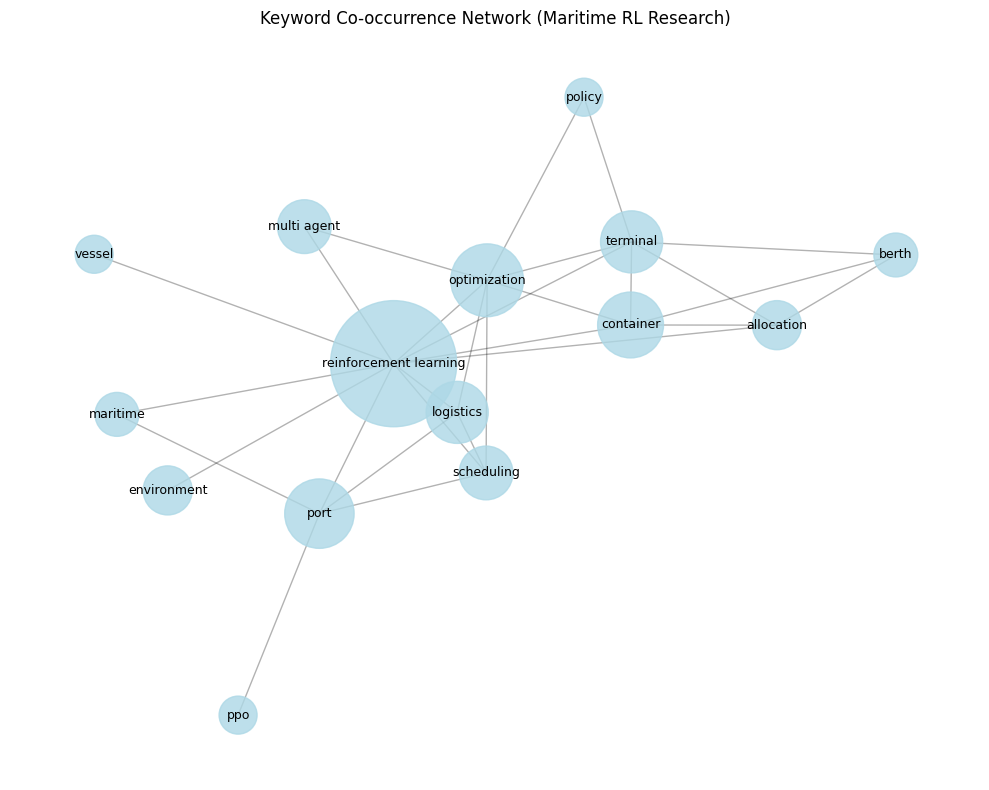

In [ ]:
import pandas as pd
import itertools
import re
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import os

# === Load dataset ===
df = pd.read_csv("maritime_rl_open_access_broad.csv")
titles = df["Title"].dropna().tolist()

# === Preprocess titles ===
def clean_text(t):
    t = t.lower()
    t = re.sub(r"[^a-z\s]", " ", t)
    return t

titles = [clean_text(t) for t in titles]

# === Define maritime and RL keywords ===
keywords = [
    "vessel", "port", "terminal", "berth", "maritime", "container", "logistics",
    "optimization", "scheduling", "allocation", "rotation", "shipping",
    "reinforcement learning", "ppo", "q-learning", "dqn", "actor critic", "policy",
    "multi agent", "deep learning", "prediction", "simulation", "environment"
]

# === Extract keyword co-occurrences ===
cooccurrences = Counter()
for t in titles:
    found = [k for k in keywords if k in t]
    for combo in itertools.combinations(sorted(found), 2):
        cooccurrences[combo] += 1

# === Build graph ===
G = nx.Graph()
for (kw1, kw2), w in cooccurrences.items():
    if w >= 2:  # only strong connections
        G.add_edge(kw1, kw2, weight=w)

# === Layout & visualization ===
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=0.6, seed=42)

# Node size by frequency
freq = Counter([k for t in titles for k in keywords if k in t])
sizes = [freq[n]*250 for n in G.nodes()]

# Draw
edges = nx.draw_networkx_edges(G, pos, alpha=0.3)
nodes = nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color="lightblue", alpha=0.8)
labels = nx.draw_networkx_labels(G, pos, font_size=9, font_family="sans-serif")

plt.title("Keyword Co-occurrence Network")
plt.axis("off")
os.makedirs("plots", exist_ok=True)
plt.tight_layout()
plt.savefig("plots/keyword_network.png", dpi=300)
plt.show()